# Initialize the instrument

In [1]:
from Equipments import BNC575
from Equipments import Weeder
from Equipments import SR400
from Equipments import MCBOX
from Equipments import Andor
import numpy as np
import matplotlib.pyplot as plt
import pyvisa
import time
from scipy.signal import find_peaks

In [2]:
from DataProcessing.Plot import PlotSaver

In [3]:
ps = PlotSaver("X:/migratedData/Rydberg_QIS/data")

In [4]:
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'GPIB0::9::INSTR', 'GPIB0::23::INSTR')


In [5]:
bnc575 = BNC575.BNC575("GPIB0::9::INSTR")

In [6]:
sr400 = SR400.SR400('GPIB0::23::INSTR', timeout = 1000)

In [7]:
weeder = Weeder.Weeder("ASRL1::INSTR")

In [8]:
mcbox = MCBOX.MCBOX(find_device = "USB-3114")

USB-3114 found.
Board number: 0


# define the pulse

In [142]:
pulse_arrangement = [["A", 900e-6, 0, "TTL"],              # MOT
                     [["B", 10e-6, 5e-6, 15],              # 780 EXC (20dB attenuator connected)
                      ["C", 10e-6, 5e-6, "TTL"]],          # 480 EXC
                     ["D", 20e-6, 0, 8],                   # DEI switch
                    ]
T = 1000e-6

cycle_number = 30
# photon counter gate width
gate_width = 15e-6
gate_delay = 3e-6

# stepper motor slope (for blue laser)
freq_factor = 129 * 2 #kHz

notes = {"gate_width": gate_width, "gate_delay": gate_delay}

In [117]:
sr400.counter_set(count_mode = "INDEPENDENT", count_preset = 100e-6, count_period_num = cycle_number, 
                  dwell = 0, sourceA = "INPUT1", sourceB = "INPUT2", gate_A_mode = "FIXED",
                  gate_A_delay = gate_delay, gate_A_width = gate_width, gate_B_mode = "CW")

---------------------------------------
The photon counter is now set to:

Counting Mode: INDEPENDENT
T Input: 10MHz
T Preset: 0.0001s
Period number: 30
Dwell time: External
Counter A source: INPUT1
Counter B source: INPUT2

The gate A is set to:

Delay: 3.000E-6
Width: 15.00E-6


The gate B is set to: CW
---------------------------------------


In [118]:
notes["bnc575 T0"] = bnc575.clock_set(period = T, mode = "CONTINUOUS")
notes["bnc575 pulses"] = bnc575.pulse_sequence_setup(pulse_arrangement)

---------------------------------------
The global clock is set to:
Mode: NORM
Period: 1.00e-03s
Pulses number: N/A
---------------------------------------
[['A', 0.0009, 0, 'TTL'], ['B', 1e-05, 0.000905, 15], ['C', 1e-05, 0.000905, 'TTL'], ['D', 2e-05, 0.000915, 8]]
---------------------------------------
The channel A is set to:
Width: 9.0000e-04s
Delay: 0.0000e+00s
Synchronize to: T0
Out: TTL

Output timers:
HGFEDCBA
00000001
---------------------------------------
---------------------------------------
The channel B is set to:
Width: 1.0000e-05s
Delay: 9.0500e-04s
Synchronize to: T0
Out: 15.00

Output timers:
HGFEDCBA
00000010
---------------------------------------
---------------------------------------
The channel C is set to:
Width: 1.0000e-05s
Delay: 9.0500e-04s
Synchronize to: T0
Out: TTL

Output timers:
HGFEDCBA
00000100
---------------------------------------
---------------------------------------
The channel D is set to:
Width: 2.0000e-05s
Delay: 9.1500e-04s
Synchronize 

In [119]:
bnc575.start_pulses()

# search the resonance

In [14]:
weeder.position(header = "A", query = True)

'A3980'

In [18]:
weeder.move("A", position = 4000, progress = True)

start at 1000 --> 4000.0 --> 4000
Old position: 1000
New position: 4000


In [55]:
weeder.advance(header = "A", num_step = -10)

start at 3495 --> 3485.0 --> 3485
Old position: 3495
New position: 3485


# Stark map

## 1D

In [61]:
center = 3485 + 88
stride = 1
half_width = 200


# scan list gneration
x_list = np.arange(2* half_width/stride)

In [62]:
# everytime go further and go back to release the band tension and gear margin
start_position = center - half_width
weeder.move(header = "A", position = start_position - 100)
weeder.move(header = "A", position = start_position)

results = []
s = time.time()
for idx in x_list:
    print(f"now checking step: {idx}", end = "\r", flush=True)
    sr400.count_reset()
    result = np.mean(sr400.read_entire_counts(counter = "A", length = cycle_number))
    results.append(result)
    for i in range(stride):
        weeder.step("A","+")
    time.sleep(0.1)
e = time.time()
print(e-s)

start at 3785 --> 3273.0 --> 3273
Old position: 3785
New position: 3273
start at 3273 --> 3373.0 --> 3373
Old position: 3273
New position: 3373
88.34087038040161: 399.0


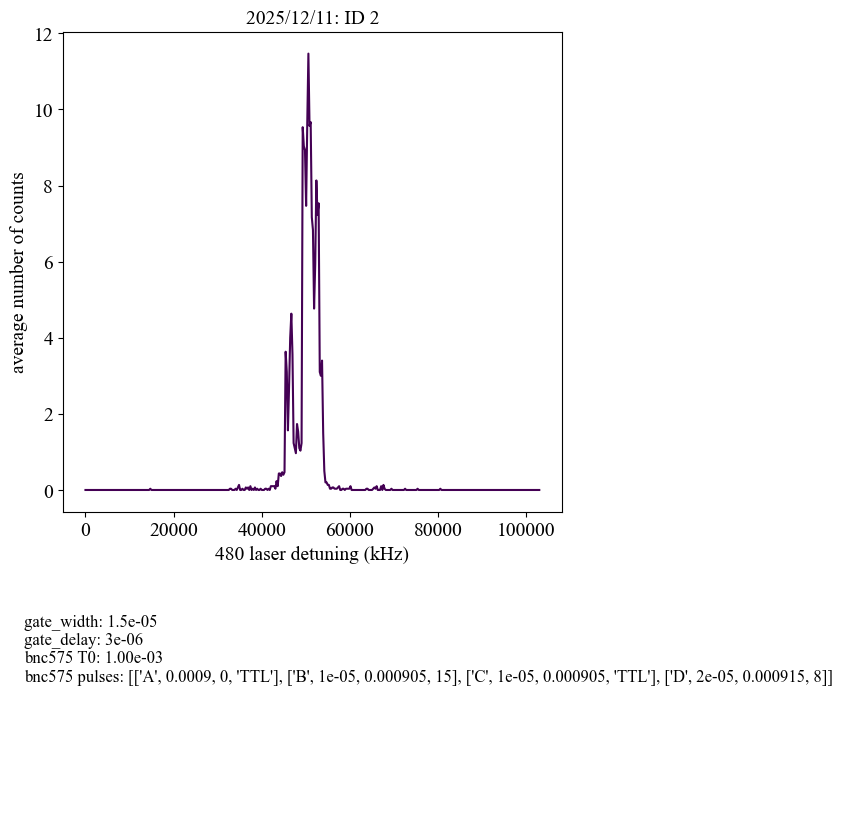

In [63]:
ps.Plot2D(x = 2*x_list*stride*freq_factor, y = None, Z = results,
          xlabel = "480 laser detuning (kHz)", zlabel = "average number of counts", notes = notes)

In [60]:
100000/(2*129)

387.5968992248062

## 2D

### frequency inside

In [ ]:
center = 3573
stride = 1
half_width = 200


# scan list gneration
x_list = np.arange(2* half_width/stride)

In [ ]:
start_position = center - half_width

v_list = np.linspace(-0.5,0.5,21) + vset[0]
stark_map = []

s = time.time()
for v in v_list:
    mcbox.set_voltage_1chan(board_num = 0, channel = 10, voltage = v, bipolar = True)
    mcbox.set_voltage_1chan(board_num = 0, channel = 11, voltage = -v, bipolar = True)
    
    # everytime go further and go back to release the band tension and gear margin
    weeder.move(header = "A", position = start_position-100)
    weeder.move(header = "A", position = start_position)
    results = []
    for idx in x_list:
        print(f"now checking step: {idx}", end = "\r", flush=True)
        sr400.count_reset()
        result = np.mean(sr400.read_entire_counts(counter="A",length = cycle_number))
        results.append(result)
        for i in range(stride):
            weeder.step("A","+")
        time.sleep(0.1)
    stark_map.append(results)

e = time.time()
print(e-s)

In [ ]:
ps.Plot3D(x = v_list, y =x_list*stride*freq_factor , Z = stark_map,
          xlabel = "x voltage (V)", ylabel = "frequency (kHz)", zlabel = "average number of counts",notes= notes)

### voltage inside

In [87]:
center = 3573
stride = 1
half_width = 200


# scan list gneration
s_list = np.arange(2* half_width/stride)

# the 0 point

#vset = np.array([0.2,-0.1,0.48])
#vset = np.array([0.19,-0.12,0.67])
vset = np.array([0.2,-0.1,0.6])

vx_list = np.linspace(-1.0,1.0,11) + vset[0]
vy_list = np.linspace(-1.0,1.0,11) + vset[1]
vz_list = np.linspace(-2.0,2.0,11) + vset[2]

v_list = np.vstack((vx_list,vy_list,vz_list))


electrode_pair = [[10,11],[6,7],[0,1]]

In [88]:
mcbox.set_voltage_1chan(board_num = 0, channel = 10, voltage = vset[0], bipolar = True, display=True)
mcbox.set_voltage_1chan(board_num = 0, channel = 11, voltage = -vset[0], bipolar = True, display=True)

mcbox.set_voltage_1chan(board_num = 0, channel = 6, voltage = vset[1], bipolar = True, display=True)
mcbox.set_voltage_1chan(board_num = 0, channel = 7, voltage = -vset[1], bipolar = True, display=True)

mcbox.set_voltage_1chan(board_num = 0, channel = 0, voltage = 0, bipolar = True, display=True)
mcbox.set_voltage_1chan(board_num = 0, channel = 1, voltage = -vset[2], bipolar = True, display=True)

Channel 10 has been set to 0.2 V.
Channel 11 has been set to -0.2 V.
Channel 6 has been set to -0.1 V.
Channel 7 has been set to 0.1 V.
Channel 0 has been set to 0 V.
Channel 1 has been set to -0.6 V.


In [89]:
start_position = center - half_width

stark_map = []

i = 0

print('Now checking axis {}'.format(i))
weeder.move(header = "A", position = start_position-100)
weeder.move(header = "A", position = start_position)
for s in s_list:
    for j in range(stride):
            weeder.step("A","+")
    print(f"now checking step: {s}", end = "\r", flush = True)
    
    results = []
    for v_s in v_list[i]:
        # scan voltage
        if electrode_pair[i][0] == 0:
            mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][0], voltage = 0, bipolar = True, display=False)
        else:
            mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][0], voltage = v_s, bipolar = True, display=False)
        mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][1], voltage = -v_s, bipolar = True, display=False)
        time.sleep(0.01)
        sr400.count_reset()
        result = np.mean(sr400.read_entire_counts(counter = "A",length = cycle_number))
        results.append(result)
        
    stark_map.append(results)

Now checking axis 0
start at 3773 --> 3273.0 --> 3273
Old position: 3773
New position: 3273
start at 3273 --> 3373.0 --> 3373
Old position: 3273
New position: 3373


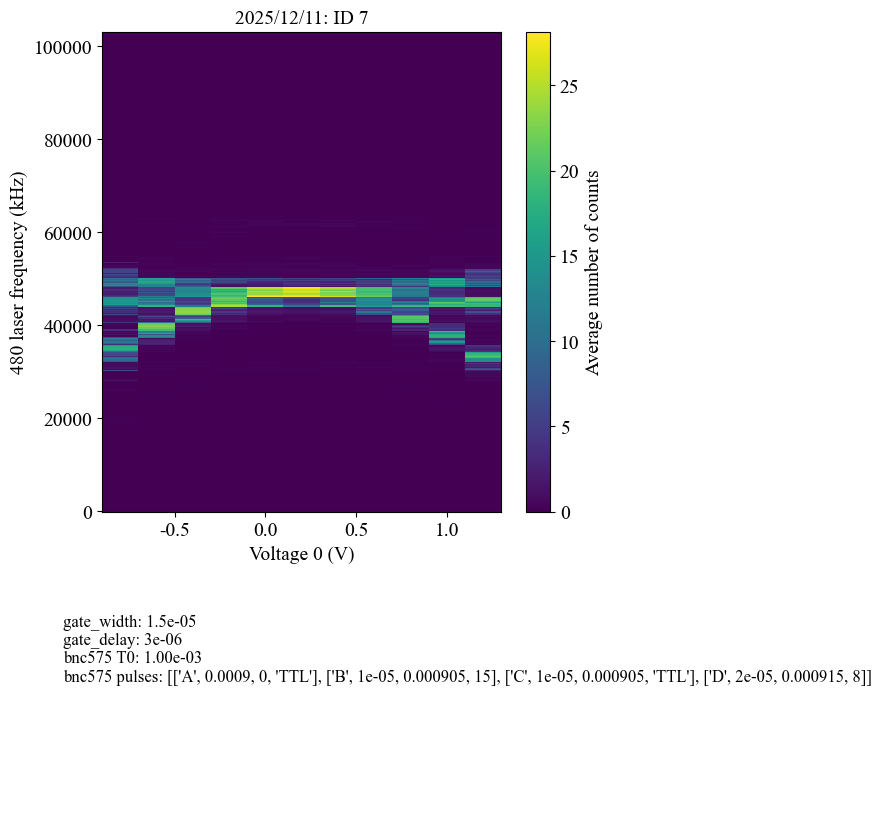

In [90]:
ps.Plot3D(x = v_list[i], y =s_list*stride*freq_factor , Z = np.array(stark_map).T,
          xlabel = f"Voltage {i} (V)", ylabel = "480 laser frequency (kHz)", zlabel = "Average number of counts", notes = notes)

### Full voltage scans (added 2025.12.11)

In [132]:
center = 3573
stride = 4
half_width = 200

# scan list gneration
s_list = np.arange(2*half_width/stride)

# the 0 point

#vset = np.array([0.2,-0.1,0.48])
#vset = np.array([0.19,-0.12,0.67])
vset = np.array([0.2,-0.1,0.6])

vx_list = np.linspace(-10.0,10.0,21) + vset[0]
vy_list = np.linspace(-10.0,10.0,21) + vset[1]
vz_list = np.linspace(-10.0,10.0,21) + vset[2]

v_list = np.vstack((vx_list,vy_list,vz_list))

electrode_pair = [[10,11],[6,7],[0,1]]

In [133]:
mcbox.set_voltage_1chan(board_num = 0, channel = 10, voltage = vset[0], bipolar = True, display=True)
mcbox.set_voltage_1chan(board_num = 0, channel = 11, voltage = -vset[0], bipolar = True, display=True)

mcbox.set_voltage_1chan(board_num = 0, channel = 6, voltage = vset[1], bipolar = True, display=True)
mcbox.set_voltage_1chan(board_num = 0, channel = 7, voltage = -vset[1], bipolar = True, display=True)

mcbox.set_voltage_1chan(board_num = 0, channel = 0, voltage = 0, bipolar = True, display=True)
mcbox.set_voltage_1chan(board_num = 0, channel = 1, voltage = -vset[2], bipolar = True, display=True)

Channel 10 has been set to 0.2 V.
Channel 11 has been set to -0.2 V.
Channel 6 has been set to -0.1 V.
Channel 7 has been set to 0.1 V.
Channel 0 has been set to 0 V.
Channel 1 has been set to -0.6 V.


In [134]:
start_position = center - half_width

stark_map = []

# electrode pair to check
i = 2

print('Now checking axis {}'.format(i))
weeder.move(header = "A", position = start_position - 100)
weeder.move(header = "A", position = start_position)

s = time.time()
print('start:',s)
for s in s_list:
    for j in range(stride):
            weeder.step("A","+")
    print(f"Now checking step: {s}", end = "\r", flush = True)
    
    results = []
    for v_s in v_list[i]:
        if v_s <= 10.0 and v_s >= -10.0:
            # scan voltage
            if electrode_pair[i][0] == 0:
                mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][0], voltage = 0, bipolar = True, display = False)
            else:
                mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][0], voltage = v_s, bipolar = True, display = False)
            mcbox.set_voltage_1chan(board_num = 0, channel = electrode_pair[i][1], voltage = -v_s, bipolar = True, display = False)
            time.sleep(0.01)
            sr400.count_reset()
            result = np.mean(sr400.read_entire_counts(counter = "A", length = cycle_number))
            results.append(result)
        else:
            continue
        
    stark_map.append(results)

e = time.time()
print('end:',e)
print('time elapsed:',e-s)

Now checking axis 2
start at 3773 --> 3273.0 --> 3273
Old position: 3773
New position: 3273
start at 3273 --> 3373.0 --> 3373
Old position: 3273
New position: 3373
start: 1765472842.4570694
end: 1765473084.5915856
time elapsed: 1765472985.5915856


In [135]:
voltages = [v for v in v_list[i] if v <= 10.0 and v >= -10.0]
print(voltages)

[-9.4, -8.4, -7.4, -6.4, -5.4, -4.4, -3.4, -2.4, -1.4, -0.4, 0.6, 1.6, 2.6, 3.6, 4.6, 5.6, 6.6, 7.6, 8.6, 9.6]


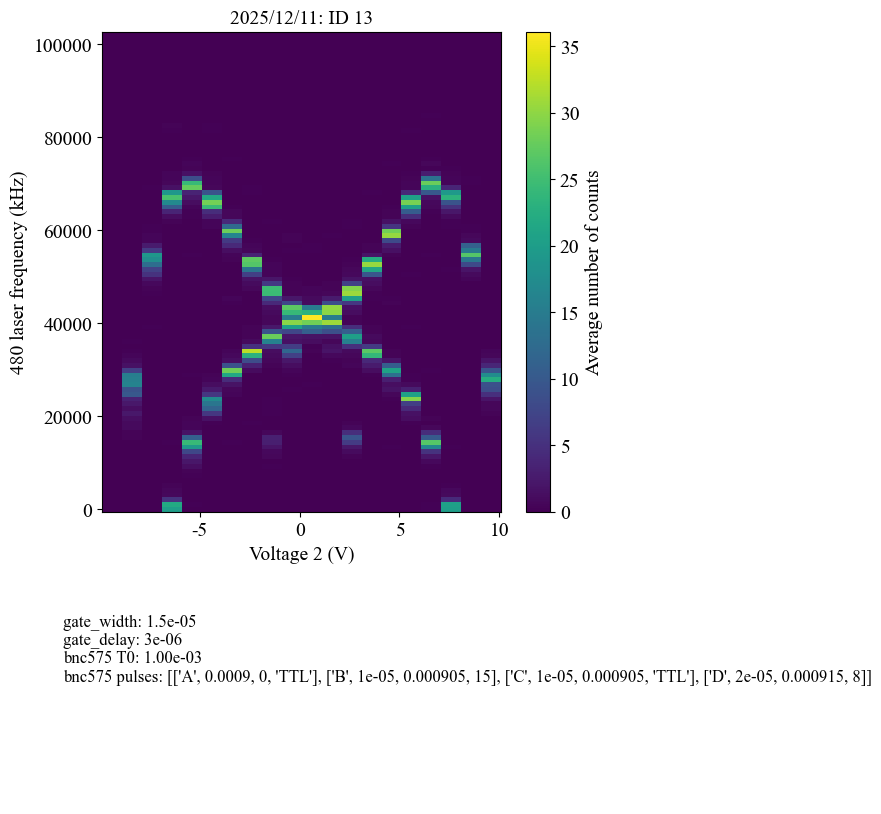

In [136]:
ps.Plot3D(x = voltages, y = s_list*stride*freq_factor , Z = np.array(stark_map).T,
          xlabel = f"Voltage {i} (V)", ylabel = "480 laser frequency (kHz)", zlabel = "Average number of counts", notes = notes)

### Peak finding and fitting

In [ ]:
print(v_list)

In [ ]:
peaks_x = []
peaks_y = []
peaks_list = []
for k in range(len(stark_map[0])):
    freq_scan = np.array(stark_map)[:,k]
    peaks,_ = find_peaks(freq_scan, height = 3, distance = 16)
    print(peaks)
    if len(peaks) == 3:
        for p in peaks:
            peaks_x.append(v_list[i][k])
            peaks_y.append((s_list*stride*freq_factor)[p])
        peaks_list.append(peaks)
peaks_list = np.array(peaks_list)
peaks_x = np.reshape(peaks_x,(-1,3)).T
peaks_y = np.reshape(peaks_y,(-1,3)).T

In [ ]:
print(v_list)

In [ ]:
plt.pcolormesh(v_list[i],s_list*stride*freq_factor,stark_map)
ssum = 0 
for l in range(3):
    a, b, c = np.polyfit(peaks_x[l], peaks_y[l], 2)
    plt.scatter(peaks_x[l],peaks_y[l])
    plt.plot(v_list[i], a * v_list[i]**2 + b * v_list[i] +c)
    plt.scatter(-b/(2*a), a * -b/(2*a)**2 + b * -b/(2*a) +c, c = "r")
    plt.xlabel(f"Voltage {i} (V)")
    plt.ylabel("Frequency (kHz)")
    ssum += -b/(2*a)
print(ssum/3)
plt.colorbar()

# End

In [137]:
mcbox.set_voltage_Nchan(board_num = 0, channels = [0,1,6,7,10,11], voltages = [0,0,0,0,0,0], bipolar = True)

Channel 0 has been set to 0 V.
Channel 1 has been set to 0 V.
Channel 6 has been set to 0 V.
Channel 7 has been set to 0 V.
Channel 10 has been set to 0 V.
Channel 11 has been set to 0 V.
Voltages successfully set.


In [138]:
weeder.save(header = "A", query = True)

'saving complete.'

In [139]:
bnc575.disable_all()

In [140]:
bnc575.disarm_all()

In [141]:
sr400.count_reset()